In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install timm medpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 12.1 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from timm.models.layers import DropPath
from medpy.metric.binary import hd95, asd

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


In [ ]:
data_root = "/content/drive/MyDrive/ISIC 2017"

image_folder = os.path.join(data_root, "ISIC-2017_Validation")
mask_folder = os.path.join(data_root, "ISIC-2017_Validation_GroundTruth")

print("Image folder exists:", os.path.exists(image_folder))
print("Mask folder exists :", os.path.exists(mask_folder))

Image folder exists: True
Mask folder exists : True


In [ ]:
def build_pairs(image_folder, mask_folder):
    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith(".jpg") and not f.startswith(".")
    ])

    mask_files = set([
        f for f in os.listdir(mask_folder)
        if f.lower().endswith(".png") and not f.startswith(".")
    ])

    pairs = []
    missing_masks = []

    for img_name in image_files:
        base = os.path.splitext(img_name)[0]
        mask_name = base + "_segmentation.png"

        img_path = os.path.join(image_folder, img_name)
        mask_path = os.path.join(mask_folder, mask_name)

        if mask_name in mask_files:
            pairs.append((img_path, mask_path))
        else:
            missing_masks.append((img_name, mask_name))

    print("JPG images found   :", len(image_files))
    print("PNG masks found    :", len(mask_files))
    print("Valid pairs found  :", len(pairs))
    print("Missing masks count:", len(missing_masks))

    if missing_masks:
        print("\nFirst 10 missing examples:")
        for item in missing_masks[:10]:
            print(item)

    return pairs

pairs = build_pairs(image_folder, mask_folder)

JPG images found   : 150
PNG masks found    : 150
Valid pairs found  : 150
Missing masks count: 0


In [ ]:
random.shuffle(pairs)
pairs = pairs[:150]
print("Using subset size:", len(pairs))

Using subset size: 150


In [ ]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val  :", len(val_pairs))
print("Test :", len(test_pairs))

Train: 105
Val  : 22
Test : 23


In [ ]:
class ISICSegDataset(Dataset):
    def __init__(self, pairs, image_size=128, train=False):
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.pairs)

    def augment(self, image, mask):
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        if random.random() > 0.5:
            angle = random.choice([90, 180, 270])
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

        return image, mask

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        if self.train:
            image, mask = self.augment(image, mask)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=self.mean, std=self.std)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 2

train_dataset = ISICSegDataset(train_pairs, image_size=IMAGE_SIZE, train=True)
val_dataset   = ISICSegDataset(val_pairs, image_size=IMAGE_SIZE, train=False)
test_dataset  = ISICSegDataset(test_pairs, image_size=IMAGE_SIZE, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 27
Val batches  : 6
Test batches : 6


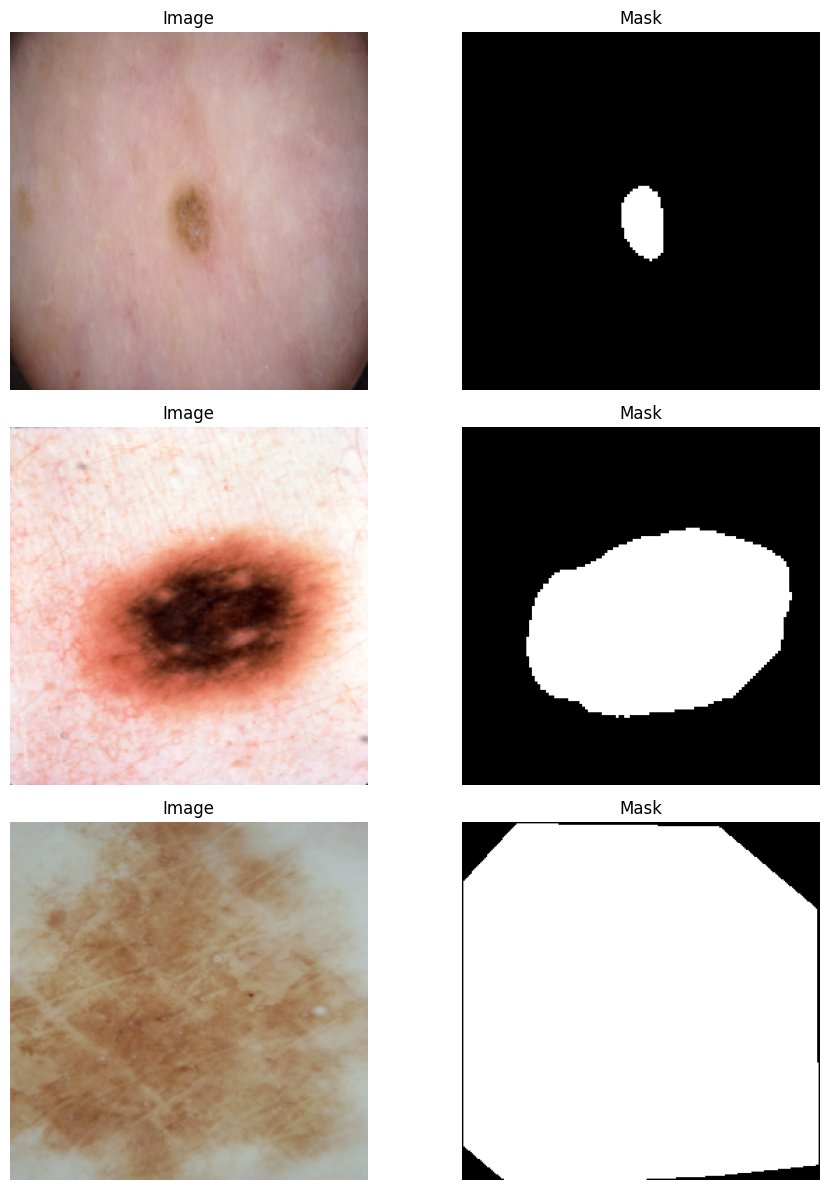

In [ ]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = img * std + mean
    return np.clip(img, 0, 1)

def show_samples(dataset, n=3):
    plt.figure(figsize=(10, 4 * n))

    for i in range(n):
        image, mask = dataset[i]
        image_np = denormalize(image.numpy()).transpose(1, 2, 0)
        mask_np = mask.squeeze().numpy()

        plt.subplot(n, 2, 2 * i + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 2, 2 * i + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataset, n=3)

In [ ]:
BNNorm2d = nn.BatchNorm2d
Activation = nn.GELU

class up_conv(nn.Module):
    def __init__(self, ch_in, ch_out):
        super(up_conv, self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=1, padding=1, bias=False),
            BNNorm2d(ch_out),
            Activation()
        )

    def forward(self, x):
        return self.up(x)

class down_conv(nn.Module):
    def __init__(self, ch_in, ch_out):
        super(down_conv, self).__init__()
        self.down = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=2, padding=1, bias=False),
            BNNorm2d(ch_out),
            Activation()
        )

    def forward(self, x):
        return self.down(x)

class ResBlock(nn.Module):
    def __init__(self, inplanes, planes, groups=1):
        super(ResBlock, self).__init__()
        self.inplanes = inplanes
        self.planes = planes
        self.conv1 = nn.Conv2d(inplanes, planes, 3, stride=1, padding=1)
        self.bn1 = BNNorm2d(planes)
        self.act = Activation()
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, groups=groups, padding=1)
        self.bn2 = BNNorm2d(planes)

        if self.inplanes != self.planes:
            self.down = nn.Sequential(
                nn.Conv2d(inplanes, planes, 1, stride=1),
                BNNorm2d(planes)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.conv2(out)

        if self.inplanes != self.planes:
            identity = self.down(x)

        out = self.bn2(out) + identity
        out = self.act(out)
        return out

class OPE(nn.Module):
    def __init__(self, inplanes, planes):
        super(OPE, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, inplanes, 3, stride=1, padding=1)
        self.bn1 = BNNorm2d(inplanes)
        self.act = Activation()
        self.down = down_conv(inplanes, planes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.down(out)
        return out

class local_block(nn.Module):
    def __init__(self, inplanes, hidden_planes, planes, groups=1, down_or_up=None):
        super(local_block, self).__init__()
        if down_or_up is None:
            self.BasicBlock = nn.Sequential(
                ResBlock(inplanes=inplanes, planes=hidden_planes, groups=groups),
            )
        elif down_or_up == 'down':
            self.BasicBlock = nn.Sequential(
                ResBlock(inplanes=inplanes, planes=hidden_planes, groups=groups),
                down_conv(hidden_planes, planes)
            )
        elif down_or_up == 'up':
            self.BasicBlock = nn.Sequential(
                ResBlock(inplanes=inplanes, planes=hidden_planes, groups=groups),
                up_conv(hidden_planes, planes),
            )

    def forward(self, x):
        return self.BasicBlock(x)

class Pooling(nn.Module):
    def __init__(self, pool_size=3):
        super().__init__()
        self.pool = nn.AvgPool2d(pool_size, stride=1, padding=pool_size//2, count_include_pad=False)

    def forward(self, x):
        return self.pool(x) - x

class GroupNorm(nn.GroupNorm):
    def __init__(self, num_channels, **kwargs):
        super().__init__(1, num_channels, **kwargs)

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, drop=0.):
        super().__init__()
        self.fc1 = nn.Conv2d(in_features, hidden_features, 1)
        self.act = Activation()
        self.fc2 = nn.Conv2d(hidden_features, out_features, 1)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class global_block(nn.Module):
    def __init__(self, in_dim, dim, num_heads, pool_size=3, mlp_ratio=4., drop=0., drop_path=0., sr_ratio=1):
        super().__init__()
        self.proj = nn.Conv2d(in_dim, dim, kernel_size=3, padding=1)
        self.norm1 = GroupNorm(dim)
        self.attn = Pooling(pool_size=pool_size)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = GroupNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, out_features=dim, drop=drop)

    def forward(self, x):
        x = self.proj(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class WNet2D(nn.Module):
    def __init__(self, in_channel=3, num_classes=1, deep_supervised=False,
                 layer_channel=[16, 32, 64, 128, 256],
                 global_dim=[8, 16, 32, 64, 128],
                 num_heads=[1, 2, 4, 8],
                 sr_ratio=[8, 4, 2, 1]):
        super(WNet2D, self).__init__()
        self.deep_supervised = deep_supervised

        self.input_l0 = nn.Sequential(
            nn.Conv2d(in_channel, layer_channel[0], kernel_size=3, stride=1, padding=1),
            BNNorm2d(layer_channel[0]),
            Activation(),
            nn.Conv2d(layer_channel[0], layer_channel[0], kernel_size=3, stride=1, padding=1),
            BNNorm2d(layer_channel[0]),
            Activation()
        )

        self.encoder1_l1_local = OPE(layer_channel[0], layer_channel[1])
        self.encoder1_l1_global = global_block(layer_channel[0], global_dim[0], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder1_l2_local = OPE(layer_channel[1], layer_channel[2])
        self.encoder1_l2_global = global_block(layer_channel[1], global_dim[1], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.encoder1_l3_local = OPE(layer_channel[2], layer_channel[3])
        self.encoder1_l3_global = global_block(layer_channel[2], global_dim[2], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.encoder1_l4_local = OPE(layer_channel[3], layer_channel[4])
        self.encoder1_l4_global = global_block(layer_channel[3], global_dim[3], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder1_l4_local = local_block(layer_channel[4], layer_channel[4], layer_channel[3], down_or_up='up')
        self.decoder1_l4_global = global_block(layer_channel[4], global_dim[4], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder1_l3_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[2], down_or_up='up')
        self.decoder1_l3_global = global_block(layer_channel[3] + global_dim[3], global_dim[3], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.decoder1_l2_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[1], down_or_up='up')
        self.decoder1_l2_global = global_block(layer_channel[2] + global_dim[2], global_dim[2], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.decoder1_l1_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[0], down_or_up='up')
        self.decoder1_l1_global = global_block(layer_channel[1] + global_dim[1], global_dim[1], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder2_l1_local = local_block(layer_channel[0] + global_dim[0], layer_channel[0], layer_channel[1], down_or_up='down')
        self.encoder2_l1_global = global_block(layer_channel[0] + global_dim[0], global_dim[0], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder2_l2_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[2], down_or_up='down')
        self.encoder2_l2_global = global_block(layer_channel[1] + global_dim[1], global_dim[1], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.encoder2_l3_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[3], down_or_up='down')
        self.encoder2_l3_global = global_block(layer_channel[2] + global_dim[2], global_dim[2], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.encoder2_l4_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[4], down_or_up='down')
        self.encoder2_l4_global = global_block(layer_channel[3] + global_dim[3], global_dim[3], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder2_l4_local_output = nn.Conv2d(layer_channel[4], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l4_local = local_block(layer_channel[4] + global_dim[4], layer_channel[4], layer_channel[3], down_or_up='up')

        self.decoder2_l3_local_output = nn.Conv2d(layer_channel[3], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l3_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[2], down_or_up='up')

        self.decoder2_l2_local_output = nn.Conv2d(layer_channel[2], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l2_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[1], down_or_up='up')

        self.decoder2_l1_local_output = nn.Conv2d(layer_channel[1], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l1_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[0], down_or_up='up')

        self.output_l0 = nn.Sequential(
            local_block(layer_channel[0] + global_dim[0], layer_channel[0], layer_channel[0], down_or_up=None),
            nn.Conv2d(layer_channel[0], num_classes, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, x):
        outputs = []

        x_e1_l0 = self.input_l0(x)

        x_e1_l1_local = self.encoder1_l1_local(x_e1_l0)
        x_e1_l0_global = self.encoder1_l1_global(x_e1_l0)

        x_e1_l2_local = self.encoder1_l2_local(x_e1_l1_local)
        x_e1_l1_global = self.encoder1_l2_global(x_e1_l1_local)

        x_e1_l3_local = self.encoder1_l3_local(x_e1_l2_local)
        x_e1_l2_global = self.encoder1_l3_global(x_e1_l2_local)

        x_e1_l4_local = self.encoder1_l4_local(x_e1_l3_local)
        x_e1_l3_global = self.encoder1_l4_global(x_e1_l3_local)

        x_d1_l3_local = self.decoder1_l4_local(x_e1_l4_local)
        x_d1_l4_global = self.decoder1_l4_global(x_e1_l4_local)

        x_d1_l3 = torch.cat((x_d1_l3_local, x_e1_l3_global), dim=1)
        x_d1_l2_local = self.decoder1_l3_local(x_d1_l3)
        x_d1_l3_global = self.decoder1_l3_global(x_d1_l3)

        x_d1_l2 = torch.cat((x_d1_l2_local, x_e1_l2_global), dim=1)
        x_d1_l1_local = self.decoder1_l2_local(x_d1_l2)
        x_d1_l2_global = self.decoder1_l2_global(x_d1_l2)

        x_d1_l1 = torch.cat((x_d1_l1_local, x_e1_l1_global), dim=1)
        x_d1_l0_local = self.decoder1_l1_local(x_d1_l1)
        x_d1_l1_global = self.decoder1_l1_global(x_d1_l1)

        x_e2_l0 = torch.cat((x_d1_l0_local, x_e1_l0_global), dim=1)
        x_e2_l1_local = self.encoder2_l1_local(x_e2_l0)
        x_e2_l0_global = self.encoder2_l1_global(x_e2_l0)

        x_e2_l1 = torch.cat((x_e2_l1_local, x_d1_l1_global), dim=1)
        x_e2_l2_local = self.encoder2_l2_local(x_e2_l1)
        x_e2_l1_global = self.encoder2_l2_global(x_e2_l1)

        x_e2_l2 = torch.cat((x_e2_l2_local, x_d1_l2_global), dim=1)
        x_e2_l3_local = self.encoder2_l3_local(x_e2_l2)
        x_e2_l2_global = self.encoder2_l3_global(x_e2_l2)

        x_e2_l3 = torch.cat((x_e2_l3_local, x_d1_l3_global), dim=1)
        x_e2_l4_local = self.encoder2_l4_local(x_e2_l3)
        x_e2_l3_global = self.encoder2_l4_global(x_e2_l3)

        outputs.append(self.decoder2_l4_local_output(x_e2_l4_local))
        x_e2_l4 = torch.cat((x_e2_l4_local, x_d1_l4_global), dim=1)
        x_d2_l3_local = self.decoder2_l4_local(x_e2_l4)

        outputs.append(self.decoder2_l3_local_output(x_d2_l3_local))
        x_d2_l3 = torch.cat((x_d2_l3_local, x_e2_l3_global), dim=1)
        x_d2_l2_local = self.decoder2_l3_local(x_d2_l3)

        outputs.append(self.decoder2_l2_local_output(x_d2_l2_local))
        x_d2_l2 = torch.cat((x_d2_l2_local, x_e2_l2_global), dim=1)
        x_d2_l1_local = self.decoder2_l2_local(x_d2_l2)

        outputs.append(self.decoder2_l1_local_output(x_d2_l1_local))
        x_d2_l1 = torch.cat((x_d2_l1_local, x_e2_l1_global), dim=1)
        x_d2_l0_local = self.decoder2_l1_local(x_d2_l1)

        x_d2_l0 = torch.cat((x_d2_l0_local, x_e2_l0_global), dim=1)
        outputs.append(self.output_l0(x_d2_l0))
        outputs = outputs[::-1]

        return outputs[0]

In [ ]:
model = WNet2D(
    in_channel=3,
    num_classes=1,
    deep_supervised=False,
    layer_channel=[8, 16, 32, 64, 128],
    global_dim=[4, 8, 16, 32, 64]
).to(device)

x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
y = model(x)
print("Output shape:", y.shape)

Output shape: torch.Size([1, 1, 256, 256])


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

criterion = BCEDiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_990/4026270.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
def dice_score(preds, targets, smooth=1e-6):
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(preds)
    return (correct / total).item()

def hd95_metric(preds, targets):
    vals = []
    preds = preds.cpu().numpy().astype(np.uint8)
    targets = targets.cpu().numpy().astype(np.uint8)

    for p, t in zip(preds, targets):
        p = p.squeeze()
        t = t.squeeze()
        if p.sum() > 0 and t.sum() > 0:
            vals.append(hd95(p, t))
    return np.mean(vals) if len(vals) > 0 else 0.0

def asd_metric(preds, targets):
    vals = []
    preds = preds.cpu().numpy().astype(np.uint8)
    targets = targets.cpu().numpy().astype(np.uint8)

    for p, t in zip(preds, targets):
        p = p.squeeze()
        t = t.squeeze()
        if p.sum() > 0 and t.sum() > 0:
            vals.append(asd(p, t))
    return np.mean(vals) if len(vals) > 0 else 0.0

In [ ]:
THRESHOLD = 0.5

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return {"loss": running_loss / len(loader)}


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0
    running_hd95 = 0.0
    running_asd = 0.0

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, masks)

        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()

        running_loss += loss.item()
        running_dice += dice_score(preds, masks)
        running_iou += iou_score(preds, masks)
        running_acc += pixel_accuracy(preds, masks)
        running_hd95 += hd95_metric(preds, masks)
        running_asd += asd_metric(preds, masks)

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
        "acc": running_acc / n,
        "hd95": running_hd95 / n,
        "asd": running_asd / n
    }

In [ ]:
EPOCHS = 100
SAVE_PATH = "/content/best_msca_lsb_isic.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_acc": [],
    "val_hd95": [],
    "val_asd": []
}

best_val_dice = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device, THRESHOLD)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_hd95"].append(val_metrics["hd95"])
    history["val_asd"].append(val_metrics["asd"])

    scheduler.step(val_metrics["dice"])

    print(f"Train Loss: {train_metrics['loss']:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f} | "
        f"Acc: {val_metrics['acc']:.4f} | "
        f"95HD: {val_metrics['hd95']:.4f} | "
        f"ASD: {val_metrics['asd']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved.")


Epoch [1/100]


Training:   0%|          | 0/27 [00:00<?, ?it/s]/tmp/ipykernel_990/3416754549.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 1.3623
Val Loss: 1.3436 | Dice: 0.0035 | IoU: 0.0018 | Acc: 0.8642 | 95HD: 121.1555 | ASD: 82.2648
Best model saved.

Epoch [2/100]


Train Loss: 1.2592
Val Loss: 1.1598 | Dice: 0.5068 | IoU: 0.3954 | Acc: 0.8777 | 95HD: 61.6455 | ASD: 31.2612
Best model saved.

Epoch [3/100]


Train Loss: 1.1970
Val Loss: 1.1590 | Dice: 0.5242 | IoU: 0.3955 | Acc: 0.8475 | 95HD: 95.7577 | ASD: 50.6936
Best model saved.

Epoch [4/100]


...

Train Loss: 0.9207
Val Loss: 0.9081 | Dice: 0.7086 | IoU: 0.6025 | Acc: 0.9129 | 95HD: 34.7177 | ASD: 18.5147

Epoch [97/100]


Train Loss: 0.9149
Val Loss: 0.8911 | Dice: 0.7095 | IoU: 0.6001 | Acc: 0.9248 | 95HD: 32.6784 | ASD: 17.2297

Epoch [98/100]


Train Loss: 0.9265
Val Loss: 0.8541 | Dice: 0.7211 | IoU: 0.6105 | Acc: 0.9305 | 95HD: 31.1974 | ASD: 15.4685

Epoch [99/100]


Train Loss: 0.9101
Val Loss: 0.9086 | Dice: 0.7009 | IoU: 0.5933 | Acc: 0.9090 | 95HD: 32.1424 | ASD: 18.4925

Epoch [100/100]


Train Loss: 0.9311
Val Loss: 0.9262 | Dice: 0.6937 | IoU: 0.5820 | Acc: 0.9170 | 95HD: 40.6541 | ASD: 20.2402


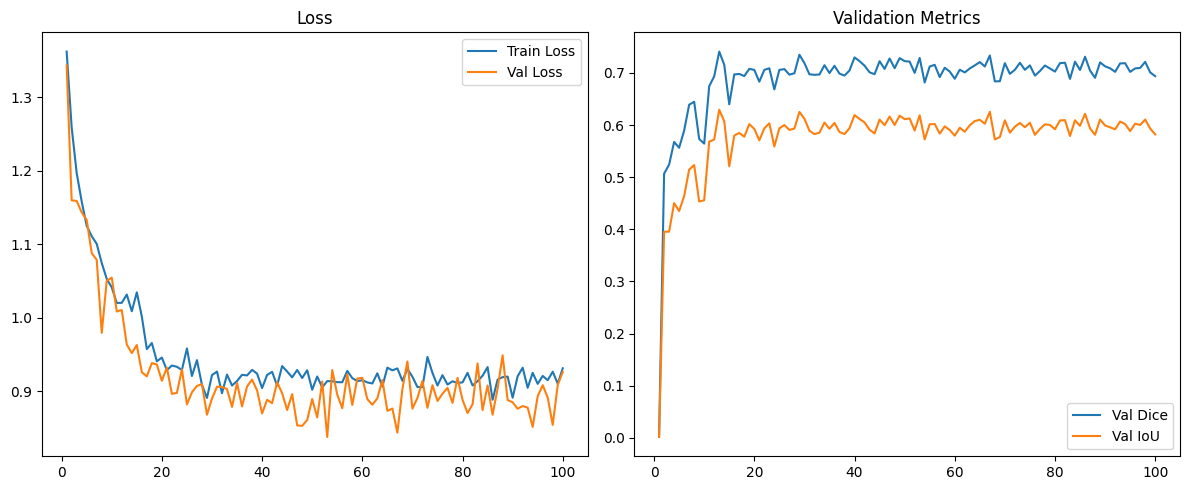

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["val_dice"], label="Val Dice")
plt.plot(epochs_range, history["val_iou"], label="Val IoU")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print("Best model loaded.")

Best model loaded.


In [ ]:
test_metrics = evaluate(model, test_loader, criterion, device, THRESHOLD)

print("\nTest Results")
print(f"Loss : {test_metrics['loss']:.4f}")
print(f"Dice : {test_metrics['dice']:.4f}")
print(f"IoU  : {test_metrics['iou']:.4f}")
print(f"Acc  : {test_metrics['acc']:.4f}")
print(f"95HD : {test_metrics['hd95']:.4f}")
print(f"ASD  : {test_metrics['asd']:.4f}")


Test Results
Loss : 1.0133
Dice : 0.6251
IoU  : 0.4999
Acc  : 0.8763
95HD : 43.2379
ASD  : 19.7060


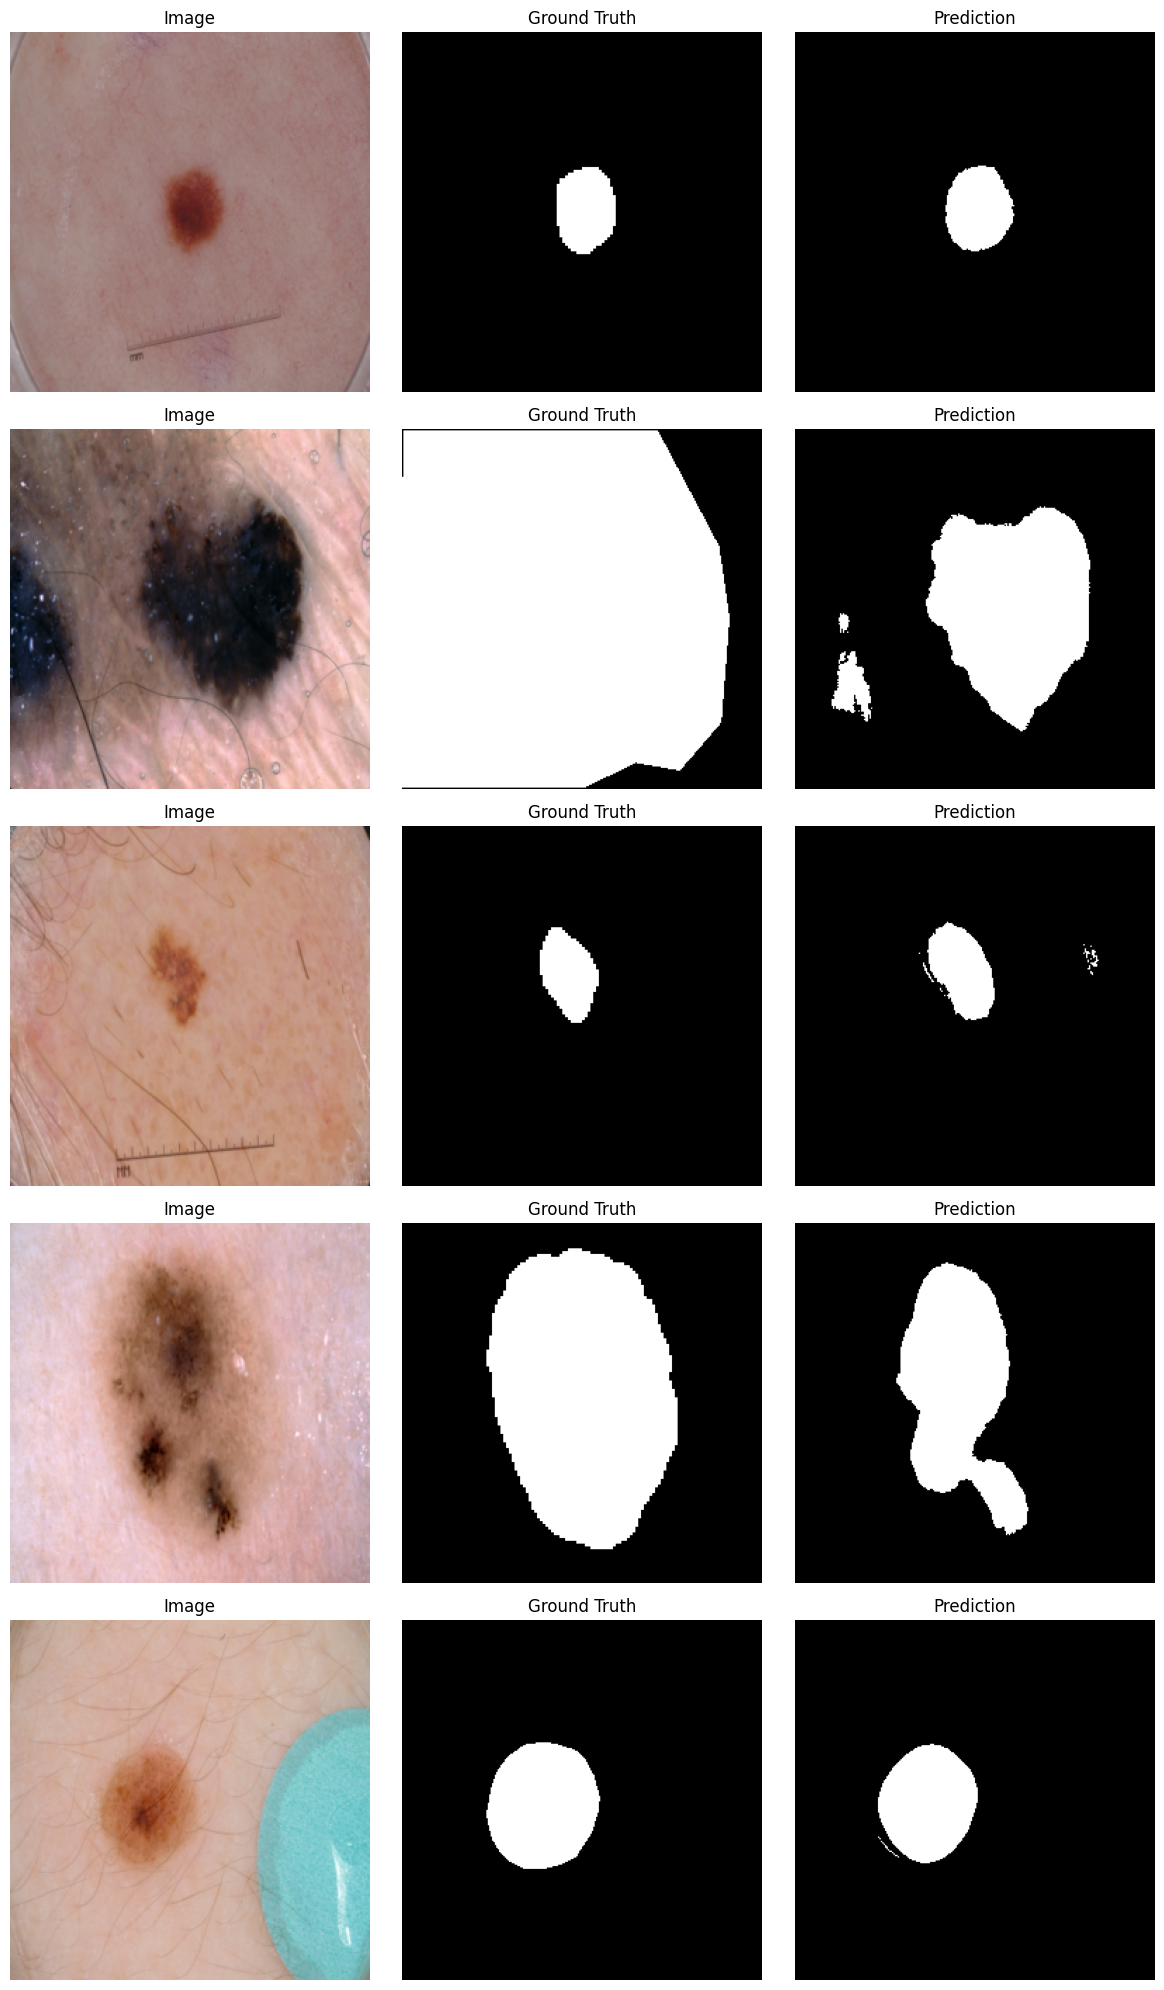

In [ ]:
@torch.no_grad()
def show_predictions(model, dataset, device, num_samples=5, threshold=0.5):
    model.eval()

    indices = np.random.choice(len(dataset), num_samples, replace=False)
    plt.figure(figsize=(12, 4 * num_samples))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        output = model(input_tensor)
        prob = torch.sigmoid(output).squeeze().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_np = denormalize(image.numpy()).transpose(1, 2, 0)
        mask_np = mask.squeeze().numpy()

        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, device, num_samples=5, threshold=THRESHOLD)

In [ ]:
results_df = pd.DataFrame([test_metrics])
results_df

,loss,dice,iou,acc,hd95,asd
0,1.013339,0.625116,0.499928,0.876261,43.237869,19.70596


In [ ]:
results_df.to_csv("/content/isic_test_results.csv", index=False)
print("Saved to /content/isic_test_results.csv")

Saved to /content/isic_test_results.csv
